In [1]:
# standard library
import sys
from pathlib import Path

# third-party
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score

# project-local
project_root = Path.cwd().parents[1]
sys.path.append(str(project_root))

from src.evaluation import evaluate_classification_model, check_overfitting

# Diabetes prediction - Train (BRFSS)

For this larger dataset (250k+ records), the additional volume supports more complex ensemble methods (Stacking and Voting) alongside Logistic Regression and Random Forest, which were the only models used for the smaller diabetes prediction dataset.

## Algorithm Selection Rationale

**Logistic Regression** is used as the interpretable baseline. Its coefficients can be directly checked against clinical expectations (e.g. higher blood pressure or cholesterol should increase predicted risk), providing a sanity check beyond raw performance metrics, and it is fast to train and tune, making it a natural starting point before more complex models.

**Random Forest** is included because several of the strongest predictors in this data are known to behave as clinical thresholds rather than linear relationships (e.g. HbA1c $\geq$ 6.5% or blood pressure classifications, as discussed in the EDA notebook), which a linear model can only approximate through a single coefficient per feature. Random Forest can capture such threshold effects and feature interactions natively through its tree-based splits, and also provides a second, independent feature importance ranking to cross-check against the Logistic Regression coefficients.

**HistGradientBoostingClassifier** specifically (rather than a standard gradient boosting or SVM implementation) is used as the third ensemble member for the reason noted before the Stacking Ensemble section: kernel SVM scales poorly at this sample size, while HistGradientBoosting is designed for large tabular datasets and trains efficiently even with 250k+ rows.

**Stacking and Voting Ensembles** are added only for this larger dataset (250k+ records), where the additional data volume better supports the added model complexity without a high risk of overfitting. Combining Logistic Regression (linear, interpretable) with Random Forest and HistGradientBoosting (both non-linear, but with different tree-building strategies - bagging vs. boosting) gives the ensemble access to diverse inductive biases. Stacking (a learned meta-combination) and Voting (a simple averaged combination) are both tested to check whether the meta-learner in Stacking adds real value over a simpler combination rule - addressed directly in the Final Comparison section.

## Load Data

In [2]:
X_train = pd.read_csv("../../data/processed/brfss_data_train.csv")
X_test = pd.read_csv("../../data/processed/brfss_data_test.csv")

In [3]:
y_train = pd.read_csv("../../data/processed/brfss_data_y_train.csv").squeeze()
y_test = pd.read_csv("../../data/processed/brfss_data_y_test.csv").squeeze()

## Cross-Validation Strategy

A `StratifiedKFold` is defined explicitly (rather than relying on the `cv=5` integer default) so that folds are shuffled reproducibly and the class balance is preserved in each fold - important given the imbalance in the diabetes target.

In [4]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Logistic Regression

### Hyperparameter Tuning

In [5]:
# Initialize Logistic Regression with balanced class weights
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

# Define hyperparameter grid for solvers and regularization
param_grid = [
    {"solver": ["lbfgs"], "penalty": ["l2"], "C": [0.01, 0.1, 1, 10, 100]},
    {"solver": ["saga"], "penalty": ["l1", "l2"], "C": [0.01, 0.1, 1, 10, 100]}
]

# Set up GridSearch to optimize ROC-AUC
grid_search_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [6]:
grid_search_lr.fit(X_train, y_train)
print(f"Best params: {grid_search_lr.best_params_}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}


### Regularization

Logistic Regression uses `C`, the inverse strength of regularization (smaller `C` = stronger penalty, shrinking coefficients more aggressively toward zero). Both L2 (`lbfgs`) and L1/L2/elasticnet (`saga`) penalties are tested. Since `lbfgs` only supports L2, the grid is split into two separate dictionaries to avoid testing invalid solver/penalty combinations.

### Prediction

In [7]:
best_lr = grid_search_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_pred_proba_lr = best_lr.predict_proba(X_test)[:, 1]

### Evaluation

=== Model Evaluation: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     42504
           1       0.34      0.77      0.47      7994

    accuracy                           0.73     50498
   macro avg       0.64      0.74      0.64     50498
weighted avg       0.85      0.73      0.76     50498

F1 (positive class): 0.4718
PR-AUC: 0.4276


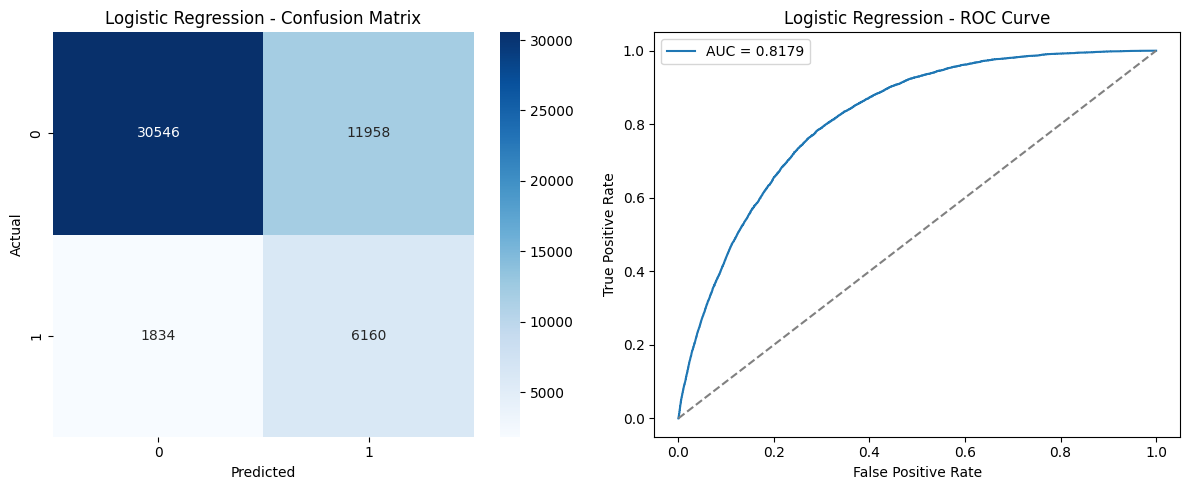

In [8]:
evaluate_classification_model(y_test, y_pred_lr, y_pred_proba_lr, model_name="Logistic Regression")

The confusion matrix shows a clear trade-off consistent with using `class_weight="balanced"`: recall on the positive (diabetic) class is high (0.77), but precision is low (0.34) - the model correctly identifies most diabetic cases, at the cost of a substantial number of false positives. This is the expected and generally preferred trade-off in a screening context, where missing an at-risk individual (false negative) is costlier than flagging a healthy one for further testing (false positive). The ROC curve (AUC = 0.818) confirms reasonable overall discrimination, though well short of near-perfect separation - consistent with the earlier EDA finding that lifestyle/demographic features are meaningfully, but not overwhelmingly, predictive of diabetes status.

In [9]:
check_overfitting(best_lr, X_train, y_train, X_test, y_test, model_name="Logistic Regression")

=== Overfitting Check: Logistic Regression ===
Train ROC-AUC: 0.8173
Test ROC-AUC:  0.8179
Gap:           -0.0006
Gap is small - no strong indication of overfitting.


### Feature Importance (Coefficients)

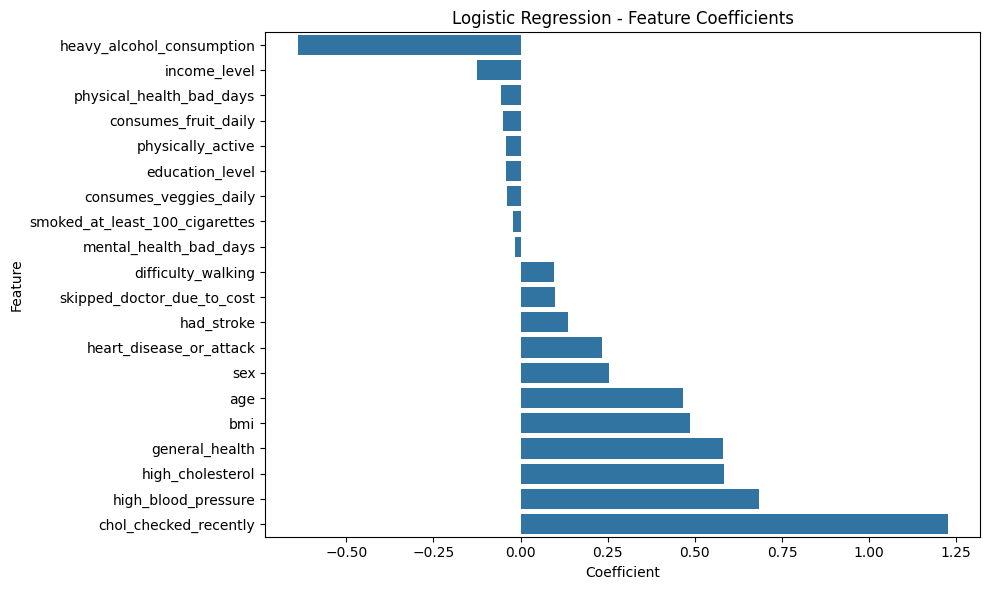

In [10]:
# Get model coefficients and map to feature names
coefficients = best_lr.coef_[0]
feature_names = X_train.columns

# Calculate absolute coefficients for ranking
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values(by="Absolute_Coefficient", ascending=False)

# Visualize feature contribution to the model
plt.figure(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Feature", data=importance_df.sort_values(by="Coefficient"))
plt.title("Logistic Regression - Feature Coefficients")
plt.tight_layout()

plt.show()

`chol_checked_recently` has by far the largest coefficient, followed by `high_blood_pressure`, `high_cholesterol`, `general_health`, `bmi`, and `age` - all positively associated with predicted diabetes risk. `heavy_alcohol_consumption` and `income_level` show the strongest negative coefficients, meaning higher alcohol consumption and higher income are both associated with lower predicted risk in this model.

The size of the `chol_checked_recently` coefficient should be interpreted with the caveat already raised in the EDA notebook: this feature likely reflects a detection/healthcare-engagement effect (people who never get their cholesterol checked are also less likely to be screened and diagnosed for diabetes) rather than a genuine physiological risk factor. Its outsized influence here is a limitation to keep in mind when interpreting this model's coefficients causally.

### Save Model

In [11]:
models_dir = Path("../../models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_lr, models_dir / "logreg_brfss_model.pkl")
print("Logistic Regression model saved.")

Logistic Regression model saved.


## Random Forest

### Regularization

For Random Forest, `max_depth` and `min_samples_split` serve an analogous role to `C` in Logistic Regression - they constrain model complexity to prevent overfitting. Shallower trees / higher `min_samples_split` act as stronger regularization; unconstrained trees (`max_depth=None`) can overfit the training data.

### Hyperparameter Tuning

In [12]:
# Initialize Random Forest with class balancing
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)

# Set hyperparameter grid for tuning tree depth and complexity
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

# Run GridSearch to optimize performance using ROC-AUC
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [13]:
grid_search_rf.fit(X_train, y_train)
print(f"Best params: {grid_search_rf.best_params_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}


### Prediction

In [14]:
best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

### Evaluation

=== Model Evaluation: Random Forest ===
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     42504
           1       0.34      0.77      0.47      7994

    accuracy                           0.73     50498
   macro avg       0.64      0.75      0.65     50498
weighted avg       0.85      0.73      0.76     50498

F1 (positive class): 0.4733
PR-AUC: 0.4521


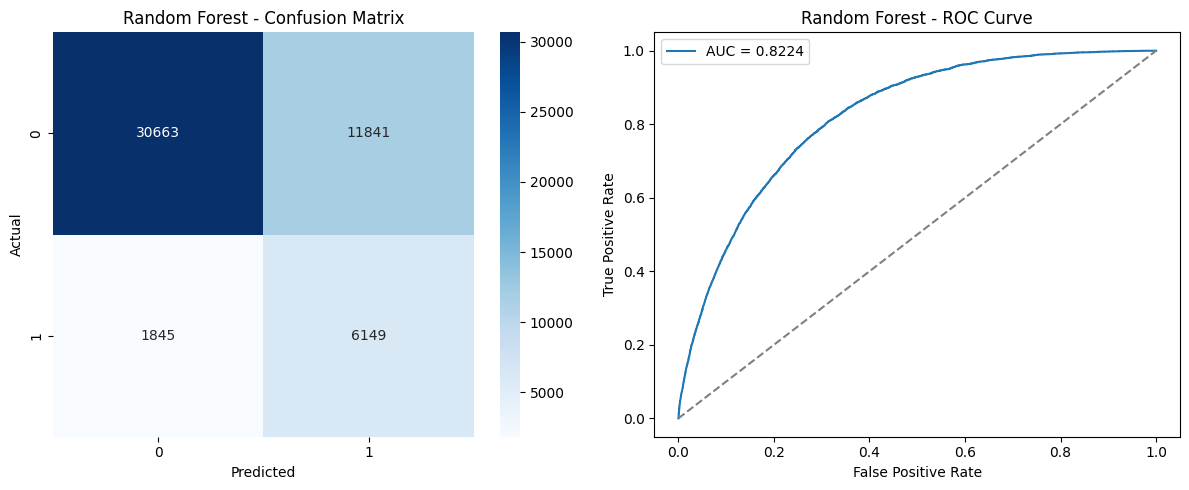

In [15]:
evaluate_classification_model(y_test, y_pred_rf, y_pred_proba_rf, model_name="Random Forest")

Random Forest correctly identifies 6,149 of 7,994 diabetic cases (recall 0.77), similar to Logistic Regression, but with a slightly better ROC-AUC (0.8224 vs. 0.8179). The confusion matrix shows a comparable trade-off: high false positive count (11,841) relative to true negatives, consistent with `class_weight="balanced"` prioritizing recall on the minority class over precision.

In [16]:
check_overfitting(best_rf, X_train, y_train, X_test, y_test, model_name="Random Forest")

=== Overfitting Check: Random Forest ===
Train ROC-AUC: 0.8380
Test ROC-AUC:  0.8224
Gap:           0.0155
Gap is small - no strong indication of overfitting.


### Feature Importance

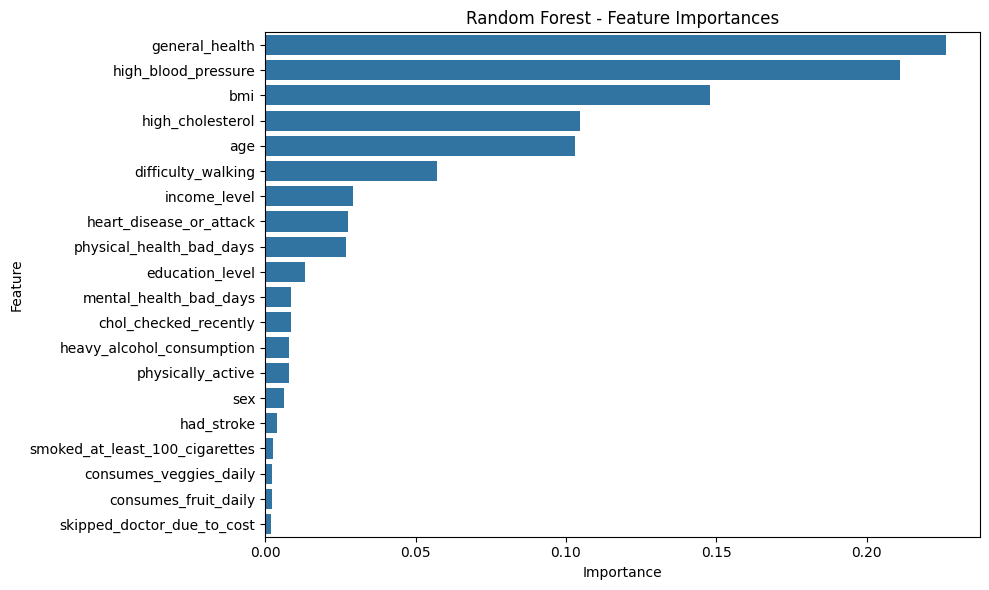

In [17]:
# Get feature importances and match with feature names
importances = best_rf.feature_importances_
feature_names = X_train.columns

# Organize into a DataFrame and sort by importance
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Visualize relative feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Random Forest - Feature Importances")
plt.tight_layout()

plt.show()

`general_health`, `high_blood_pressure`, and `bmi` rank as the most important features by Gini importance, broadly aligning with the Logistic Regression coefficients above for these three. Notably, `chol_checked_recently` - the single largest coefficient in Logistic Regression - ranks far lower here, roughly in the middle of the importance ranking. This discrepancy is informative: it suggests Logistic Regression may be more sensitive to this feature's detection-bias signal than Random Forest, which instead relies more heavily on the more clinically direct predictors (general health, blood pressure, BMI, cholesterol, age). The agreement between both models on these core features strengthens confidence that they are genuinely the most informative predictors.

### Save Model

In [18]:
joblib.dump(best_rf, models_dir / "rf_brfss_model.pkl")
print("Random Forest model saved.")

Random Forest model saved.


## Stacking Ensemble

Base estimators combine a linear model (Logistic Regression) with two non-linear learners (Random Forest, HistGradientBoosting), so the meta-learner can potentially benefit from their different inductive biases. `HistGradientBoostingClassifier` is used instead of SVM, since kernel SVM scales poorly $ (О(n^2) - o(n^3)) $ at this sample size (250k+ rows) and would make training impractically slow without a clear performance benefit over tree-based alternatives.

### Hyperparameter Tuning

In [19]:
# Define diverse base learners for the stacking ensemble
base_estimators = [
    ("lr", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", C=0.1)),
    ("rf", RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, class_weight="balanced", n_jobs=-1)),
    ("hgb", HistGradientBoostingClassifier(random_state=42, class_weight="balanced", max_leaf_nodes=31))
]

# Set the meta-learner to combine base model predictions
meta_learner = LogisticRegression(class_weight="balanced", random_state=42)

# Configure the Stacking Classifier
stacking_ensemble = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=cv_strategy,
    n_jobs=-1
)

# Define search grid for fine-tuning the ensemble
param_grid_stack = {
    "hgb__max_iter": [50, 100],
    "final_estimator__C": [0.1, 1.0]
}

# Execute GridSearch to optimize the ensemble configuration
grid_search_ensemble = GridSearchCV(
    estimator=stacking_ensemble,
    param_grid=param_grid_stack,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

In [20]:
grid_search_ensemble.fit(X_train, y_train)
print(f"Best params: {grid_search_ensemble.best_params_}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'final_estimator__C': 1.0, 'hgb__max_iter': 100}


### Prediction

In [21]:
best_ensemble_model = grid_search_ensemble.best_estimator_

y_pred_ensemble = best_ensemble_model.predict(X_test)
y_pred_proba_ensemble = best_ensemble_model.predict_proba(X_test)[:, 1]

c:\Users\vlads\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\vlads\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\vlads\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vlads\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036

> **Note:** This warning is a known, harmless issue with `joblib`'s `loky` backend on Windows - it falls back to using logical core count instead of physical, which does not affect the correctness of the results, only potentially suboptimal parallelism. It can be silenced by setting `LOKY_MAX_CPU_COUNT` to a specific number of cores (e.g. `os.environ["LOKY_MAX_CPU_COUNT"] = "4"`) on the top of the notebook. However, this is intentionally left unset here, since hardcoding a specific core count would not generalize to whoever runs this notebook on a different machine - the grader's CPU may have a different number of cores available.

### Evaluation

=== Model Evaluation: Stacking Ensemble (LR + RF + HGB) ===
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     42504
           1       0.34      0.79      0.47      7994

    accuracy                           0.72     50498
   macro avg       0.64      0.75      0.64     50498
weighted avg       0.85      0.72      0.76     50498

F1 (positive class): 0.4734
PR-AUC: 0.4565


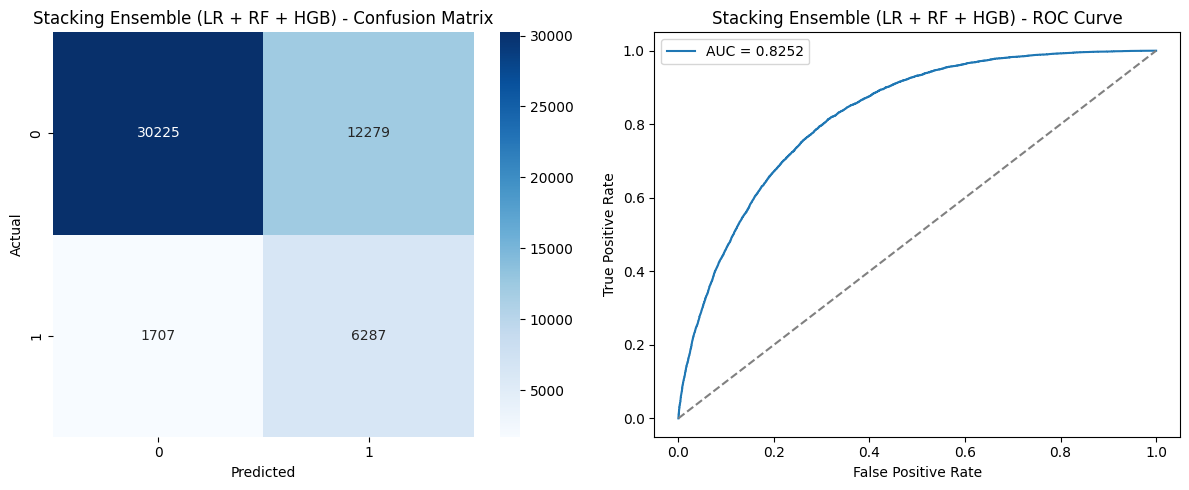

In [22]:
evaluate_classification_model(
    y_test, y_pred_ensemble, y_pred_proba_ensemble,
    model_name="Stacking Ensemble (LR + RF + HGB)"
)

In [23]:
check_overfitting(best_ensemble_model, X_train, y_train, X_test, y_test, model_name="Stacking Ensemble")

=== Overfitting Check: Stacking Ensemble ===
Train ROC-AUC: 0.8356
Test ROC-AUC:  0.8252
Gap:           0.0103
Gap is small - no strong indication of overfitting.


The Stacking Ensemble achieves the highest recall among all four models (6,287 of 7,994 correctly identified, recall 0.79), at the cost of the highest false positive count (12,279) and the lowest overall accuracy (0.72). This reflects the ensemble leaning further toward catching positive cases, consistent with its combination of Logistic Regression, Random Forest, and HistGradientBoosting each contributing to a more aggressive positive-class prediction. This is also the model with the highest ROC-AUC (0.8252) and PR-AUC (0.4565) overall.

### Save Model

In [24]:
joblib.dump(best_ensemble_model, models_dir / "stacking_ensemble_brfss_model.pkl")
print("Stacking ensemble model saved.")

Stacking ensemble model saved.


## Voting Ensemble

As a comparison to stacking (which learns how to combine predictions via a meta-learner), soft voting simply averages predicted probabilities across the same three base estimators, weighting each equally. This tests whether the meta-learner in stacking adds real value over a simpler combination rule.

### Hyperparameter Tuning

Unlike the models above, `VotingClassifier` is not tuned via `GridSearchCV` here - it directly reuses the same tuned base estimators (`lr`, `rf`, `hgb`) already selected for the Stacking Ensemble. This keeps the base models identical between Stacking and Voting, isolating the comparison to the combination strategy itself (learned meta-model vs. simple averaging) rather than confounding it with different underlying hyperparameters.

In [25]:
voting_ensemble = VotingClassifier(
    estimators=base_estimators,
    voting="soft",
    n_jobs=-1
)

In [26]:
voting_ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=0.1, class_weight='balanced',
                                                 max_iter=1000,
                                                 random_state=42)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=12,
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('hgb',
                              HistGradientBoostingClassifier(class_weight='balanced',
                                                             random_state=42))],
                 n_jobs=-1, voting='soft')

In [27]:
y_pred_voting = voting_ensemble.predict(X_test)
y_pred_proba_voting = voting_ensemble.predict_proba(X_test)[:, 1]

### Evaluation

=== Model Evaluation: Voting Ensemble (LR + RF + HGB) ===
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     42504
           1       0.34      0.78      0.48      7994

    accuracy                           0.73     50498
   macro avg       0.64      0.75      0.65     50498
weighted avg       0.85      0.73      0.76     50498

F1 (positive class): 0.4751
PR-AUC: 0.4542


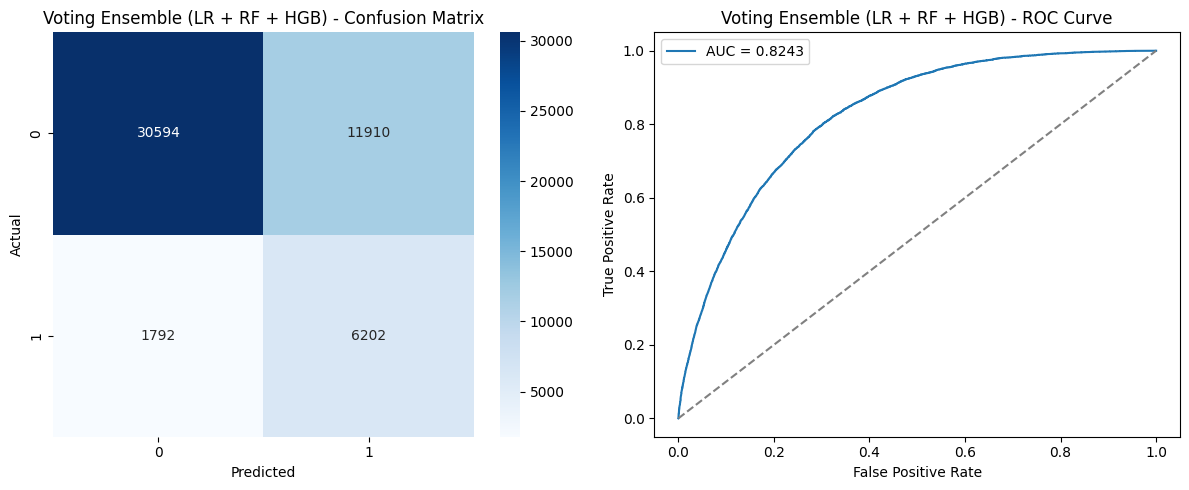

In [28]:
evaluate_classification_model(
    y_test, y_pred_voting, y_pred_proba_voting,
    model_name="Voting Ensemble (LR + RF + HGB)"
)

The Voting Ensemble sits between Random Forest and Stacking on most metrics (recall 0.78, ROC-AUC 0.8243), and achieves the highest F1 (0.4751) among all four models - a marginally better balance between precision and recall than any individual model or the Stacking Ensemble.

In [29]:
check_overfitting(voting_ensemble, X_train, y_train, X_test, y_test, model_name="Voting Ensemble")

=== Overfitting Check: Voting Ensemble ===
Train ROC-AUC: 0.8391
Test ROC-AUC:  0.8243
Gap:           0.0148
Gap is small - no strong indication of overfitting.


### Save Model

In [30]:
joblib.dump(voting_ensemble, models_dir / "voting_ensemble_brfss_model.pkl")
print("Voting ensemble model saved.")

Voting ensemble model saved.


## Final Comparison (BRFSS Dataset)

In [31]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Stacking Ensemble", "Voting Ensemble"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_ensemble),
        roc_auc_score(y_test, y_pred_proba_voting)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ensemble),
        f1_score(y_test, y_pred_voting)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_pred_proba_lr),
        average_precision_score(y_test, y_pred_proba_rf),
        average_precision_score(y_test, y_pred_proba_ensemble),
        average_precision_score(y_test, y_pred_proba_voting)
    ]
})

print(comparison.sort_values(by="ROC-AUC", ascending=False))

                 Model   ROC-AUC        F1    PR-AUC
2    Stacking Ensemble  0.825230  0.473419  0.456460
3      Voting Ensemble  0.824344  0.475140  0.454245
1        Random Forest  0.822416  0.473291  0.452081
0  Logistic Regression  0.817878  0.471814  0.427637


| Model | ROC-AUC | F1 | PR-AUC |
|---|---|---|---|
| Stacking Ensemble | 0.8252 | 0.4734 | 0.4565 |
| Voting Ensemble | 0.8243 | 0.4751 | 0.4542 |
| Random Forest | 0.8224 | 0.4733 | 0.4521 |
| Logistic Regression | 0.8179 | 0.4718 | 0.4276 |

**Key observations:**

All four models perform similarly on ROC-AUC (0.818–0.825) and F1 (0.472–0.475), suggesting that most of the predictive signal in this dataset is captured even by the simplest model (Logistic Regression). The ensembles provide a modest but consistent improvement over the individual base models, with the Stacking Ensemble achieving the highest ROC-AUC and PR-AUC, while Voting achieves a marginally higher F1. The very small difference between Stacking and Voting (0.0009 ROC-AUC) suggests the meta-learner in Stacking adds only a small amount of value beyond a simple equal-weighted average of the same three base models.

PR-AUC shows the largest relative improvement from Logistic Regression (0.428) to the tree-based models and ensembles (0.452–0.457) - meaningful given the class imbalance, where PR-AUC is more sensitive to performance on the minority (diabetic) class than ROC-AUC.

The overfitting checks (train vs. test ROC-AUC gap) were small across all models (0.010–0.016, with Logistic Regression showing an essentially zero, slightly negative gap), indicating none of the models memorized the training data - the tuned hyperparameters (e.g. `max_depth=10` for Random Forest, moderate regularization for Logistic Regression) successfully controlled model complexity.

Given the marginal gains from ensembling and the added complexity/training time of Stacking in particular, Random Forest offers a reasonable practical balance between performance and simplicity, while the Stacking Ensemble is retained as the top-performing model for final reporting.